In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from lightgbm import LGBMRegressor, plot_tree
from xgboost import XGBRegressor
from lazypredict.Supervised import LazyRegressor

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle
import joblib
import cloudpickle
import onnx
import skops.io as sio

In [2]:

# Chargement des données
data = pd.read_csv('../../data/dataset_pv_variability_paca_2020_2024.csv', index_col=0).dropna()

# Création de variables retardées (lags) pour capturer la mémoire temporelle du système
data["tch_lag_1"] = data["tch"].shift(1)
data["tch_lag_2"] = data["tch"].shift(2)
data["tch_lag_3"] = data["tch"].shift(3)

# Lags des variations d’irradiance
data["dghi_lag_1"] = data["dghi_dt"].shift(1)
data["dghi_lag_2"] = data["dghi_dt"].shift(2)
data["dghi_lag_3"] = data["dghi_dt"].shift(3)

# Lags de la variabilité cible
data["dtch_lag_1"] = data["target_variability"].shift(1)
data["dtch_lag_2"] = data["target_variability"].shift(2)
data["dtch_lag_3"] = data["target_variability"].shift(3)

# Lags des variations de nuages
data["dcloud_lag_1"] = data["dcloud_dt"].shift(1)
data["dcloud_lag_2"] = data["dcloud_dt"].shift(2)

# Indicateur jour / nuit
data["is_night"] = (data["ghi_region"] <= 0).astype(int)

# Lag supplémentaire sur l’irradiance globale
data["ghi_lag_3"] = data["ghi_region"].shift(3)

# Suppression des NaN créés par les lags
df = data.dropna().copy()

# Séparation chronologique des données :
# - train   : années jusqu’à 2022
# - valid   : année 2023
# - test    : année 2024
# Ce découpage respecte la nature temporelle du problème
# et évite la fuite d’information entre passé et futur.
train = df.loc[df['year'] <= 2022].copy()
valid = df.loc[df['year'] == 2023].copy()
test = df.loc[df['year'] == 2024].copy()

# Liste des variables explicatives
features = ["sin_hour", "cos_hour", "sin_doy", "cos_doy",
    "dghi_dt", "dcloud_dt",
    "cloud_lag_1", "cloud_lag_2", "dcloud_lag_1", "dcloud_lag_2", "cloud_cover_region",
    "is_night", "tch_lag_1", "tch_lag_2", "tch_lag_3",
    "ghi_lag_1", "ghi_lag_2", "ghi_lag_3", "dghi_lag_1", "dghi_lag_2", "dghi_lag_3",
    "dtch_lag_1", "dtch_lag_2", "dtch_lag_3", "toa_irradiance_region", "season",
    "solar_azimuth_region", "solar_altitude_region", "temperature_region",
    "ghi_region", "bhi_region", "dhi_region", "dni_region", "wind_speed_region", "humidity_region",
    "clear_sky_ghi_region", "clear_sky_bhi_region", "clear_sky_dhi_region", "clear_sky_dni_region", "month"]

# Suppression des éventuels doublons dans la liste des features
features = list(dict.fromkeys(features))
    
# # Construction des matrices d’entrée et de sortie
X_train = train[features]
y_train = train["target_variability"]

X_valid = valid[features]
y_valid = valid["target_variability"]

X_test = test[features]
y_test = test["target_variability"]

# Séparation colonnes numériques / catégorielles
num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

# Pipeline de normalisation des variables numériques
numeric_scale = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Encodage one-hot pour les variables catégorielles
categorical_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Préprocesseur non scalé
# - Les variables numériques sont conservées telles quelles (pas de scaling)
# - Les variables catégorielles sont transformées en variables binaires (One-Hot Encoding)
preprocess_unscaled = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# Préprocesseur scalé :
# - Les variables numériques sont standardisées (StandardScaler)
# - Les variables catégorielles sont encodées en variables binaires (One-Hot Encoding)
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scale, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# Application du preprocessing normalisé
scaled = preprocess_scaled.fit(X_train)
# Récupération des noms des colonnes transformées, supprimer le préfixe 'num__' ou 'cat__'
cols = [name[5:] for name in preprocess_scaled.get_feature_names_out()]
# Transformation des jeux train / validation / test
X_train_scaled = pd.DataFrame(
    preprocess_scaled.transform(X_train),
    columns=cols,
    index=X_train.index
)

X_valid_scaled = pd.DataFrame(
    preprocess_scaled.transform(X_valid),
    columns=cols,
    index=X_valid.index
)

X_test_scaled = pd.DataFrame(
    preprocess_scaled.transform(X_test),
    columns=cols,
    index=X_test.index
)

# Application du preprocessing nonnormalisé
unscaled = preprocess_unscaled.fit(X_train)
cols = [name[5:] for name in preprocess_unscaled.get_feature_names_out()]
X_train = pd.DataFrame(
    preprocess_unscaled.transform(X_train),
    columns=cols,
    index=X_train.index
)

X_valid = pd.DataFrame(
    preprocess_unscaled.transform(X_valid),
    columns=cols,
    index=X_valid.index
)

X_test = pd.DataFrame(
    preprocess_unscaled.transform(X_test),
    columns=cols,
    index=X_test.index
)


In [3]:
# LazyRegressor + MAE + MAE relatif
def run_lazy(X_train, X_valid, y_train, y_valid, label):
    """Fonction qui exécute LazyPredict sur un jeu d'entraînement et de validation
    et qui calcule en plus le MAE et le MAE relatif (%)"""

    # Initialisation de LazyRegressor
    reg = LazyRegressor(verbose=1, ignore_warnings=True, random_state=42, predictions=True)

    # Entraîne tous les modèles de LazyPredict
    # models : tableau contenant les métriques calculées par LazyPredict
    # preds : DataFrame contenant les prédictions de chaque modèle
    models, preds = reg.fit(X_train, X_valid, y_train, y_valid)

    # Calcul de la moyenne des valeurs réelles de validation
    # utilisée pour calculer le MAE relatif
    y_mean = y_valid.mean()

    # Dictionnaires pour stocker les scores
    mae_scores = {}
    mae_rel_scores = {}

    # Boucle sur chaque modèle testé
    for model_name in preds.columns:
        # Prédictions du modèle courant
        pred = preds[model_name]

        # Calcul du MAE (Mean Absolute Error)
        mae = mean_absolute_error(y_valid, pred)

        # Calcul du MAE relatif en pourcentage
        mae_rel = round(mae / y_mean * 100, 2) if y_mean != 0 else np.nan

        # Stockage des résultats
        mae_scores[model_name] = mae
        mae_rel_scores[model_name] = mae_rel

    # Conversion des dictionnaires en DataFrame
    mae_df = pd.DataFrame({
        "MAE": pd.Series(mae_scores),
        "MAE_relatif(%)": pd.Series(mae_rel_scores)
    })

    # Fusion des scores MAE avec les résultats fournis par LazyPredict
    # l'index correspond au nom des modèles
    out = models.merge(mae_df, left_index=True, right_index=True)

    # Ajout d'une colonne indiquant si les données sont scalées ou non
    out["scaling_mode"] = label

    return out


# Exécuter LazyPredict sur les données non scalées
results_unscaled = run_lazy(X_train, X_valid, y_train, y_valid, "unscaled")

# Exécuter LazyPredict sur les données scalées
results_scaled = run_lazy(X_train_scaled, X_valid_scaled, y_train, y_valid, "scaled")

# Combiner les résultats des deux configurations
models_df = pd.concat([results_unscaled, results_scaled])

# Renommer certaines colonnes pour avoir des noms plus explicites
models_df = models_df.rename({
    "R-Squared": "r2_score",
    "Time Taken": "temps_execution"
}, axis=1)

# Sélectionner uniquement les colonnes utiles pour l'analyse
models_df = models_df[
    ["r2_score", "MAE", "RMSE", "MAE_relatif(%)", "scaling_mode", "temps_execution"]
]

# Sauvegarde les résultats de LazyPredict dans un fichier CSV
# pour éviter de relancer l'entraînement (qui prend du temps)
models_df.reset_index(names="Model").to_csv("models_2024_lazy_predict.csv", index=False)
models_df.reset_index(names="Model").set_index('Model').head()
models_df.loc[models_df["r2_score"] > 0].sort_values(["MAE", "r2_score"], ascending=[True, False]).head(40)

  0%|          | 0/42 [00:00<?, ?it/s]

{'Model': 'AdaBoostRegressor', 'R-Squared': 0.5033949181802613, 'Adjusted R-Squared': 0.5021730127946897, 'RMSE': np.float64(2.419273444816544), 'Time taken': 19.090568780899048}
{'Model': 'BaggingRegressor', 'R-Squared': 0.9178657606603231, 'Adjusted R-Squared': 0.917663667945079, 'RMSE': np.float64(0.9838785635996746), 'Time taken': 20.05289578437805}
{'Model': 'BayesianRidge', 'R-Squared': 0.8680791905685573, 'Adjusted R-Squared': 0.8677545971372486, 'RMSE': np.float64(1.2469126542736075), 'Time taken': 0.29821205139160156}
{'Model': 'DecisionTreeRegressor', 'R-Squared': 0.8515570879145327, 'Adjusted R-Squared': 0.8511918415641277, 'RMSE': np.float64(1.3226931715357864), 'Time taken': 3.0813159942626953}
{'Model': 'DummyRegressor', 'R-Squared': -0.0019438939815170642, 'Adjusted R-Squared': -0.004409194247092962, 'RMSE': np.float64(3.436379188516993), 'Time taken': 0.1180109977722168}
{'Model': 'ElasticNet', 'R-Squared': 0.681394264310718, 'Adjusted R-Squared': 0.6806103293922792, 'R

  0%|          | 0/42 [00:00<?, ?it/s]

{'Model': 'AdaBoostRegressor', 'R-Squared': 0.5033949181802613, 'Adjusted R-Squared': 0.5021730127946897, 'RMSE': np.float64(2.419273444816544), 'Time taken': 17.51051616668701}
{'Model': 'BaggingRegressor', 'R-Squared': 0.9178657606603231, 'Adjusted R-Squared': 0.917663667945079, 'RMSE': np.float64(0.9838785635996746), 'Time taken': 18.800525426864624}
{'Model': 'BayesianRidge', 'R-Squared': 0.8680791905685998, 'Adjusted R-Squared': 0.8677545971372912, 'RMSE': np.float64(1.2469126542734064), 'Time taken': 0.25078892707824707}
{'Model': 'DecisionTreeRegressor', 'R-Squared': 0.8515570879145327, 'Adjusted R-Squared': 0.8511918415641277, 'RMSE': np.float64(1.3226931715357864), 'Time taken': 2.8471877574920654}
{'Model': 'DummyRegressor', 'R-Squared': -0.0019438939815170642, 'Adjusted R-Squared': -0.004409194247092962, 'RMSE': np.float64(3.436379188516993), 'Time taken': 0.10667872428894043}
{'Model': 'ElasticNet', 'R-Squared': 0.6813942643107563, 'Adjusted R-Squared': 0.6806103293923175, 

,r2_score,MAE,RMSE,MAE_relatif(%),scaling_mode,temps_execution
NuSVR,0.93,0.44,0.90,17.05,scaled,484.97
NuSVR,0.93,0.44,0.90,17.05,unscaled,521.52
ExtraTreesRegressor,0.92,0.44,0.94,17.31,unscaled,49.34
ExtraTreesRegressor,0.92,0.44,0.94,17.31,scaled,46.22
SVR,0.93,0.44,0.90,17.34,scaled,149.22
SVR,0.93,0.44,0.90,17.34,unscaled,143.24
RandomForestRegressor,0.92,0.45,0.95,17.42,unscaled,190.17
RandomForestRegressor,0.92,0.45,0.95,17.42,scaled,191.50
LGBMRegressor,0.92,0.45,0.94,17.80,scaled,0.55
HistGradientBoostingRegressor,0.92,0.46,0.94,17.83,unscaled,2.91


| Catégorie                          | Idée                                                         |
| ---------------------------------- | ------------------------------------------------------------ |
| **Modèles linéaires**              | supposent une relation linéaire entre variables              |
| **Machines à vecteurs de support (SVM)** | modèles non linéaires utilisant des noyaux                   |
| **Arbres de décision**             | règles de décision successives (tests sur les variables)     |
| **Ensembles d’arbres**             | combinaison de plusieurs arbres pour améliorer la prédiction (RandomForest, XGBoost…) |
| **Réseaux de neurones**            | modèles non linéaires (MLPRegressor)                   |
| **Méthodes à base de voisins**     | prédiction basée sur les k échantillons d’apprentissage les plus proches (selon une distance) du nouveau point (KNN)       |
| **Méthodes particulières**                   | modèles utilisant des stratégies particulières d’apprentissage ou de transformation pour améliorer la prédiction (TransformedTargetRegressor, PassiveAggressiveRegressor)         |


In [4]:
model_categories = {

# Modèles linéaires
'LinearRegression': 'Modèles linéaires',
'Ridge': 'Modèles linéaires',
'RidgeCV': 'Modèles linéaires',
'Lasso': 'Modèles linéaires',
'LassoCV': 'Modèles linéaires',
'ElasticNet': 'Modèles linéaires',
'ElasticNetCV': 'Modèles linéaires',
'BayesianRidge': 'Modèles linéaires',
'HuberRegressor': 'Modèles linéaires',
'SGDRegressor': 'Modèles linéaires',
'LarsCV': 'Modèles linéaires',
'LassoLars': 'Modèles linéaires',
'LassoLarsCV': 'Modèles linéaires',
'LassoLarsIC': 'Modèles linéaires',
'OrthogonalMatchingPursuit': 'Modèles linéaires',
'OrthogonalMatchingPursuitCV': 'Modèles linéaires',
'PoissonRegressor': 'Modèles linéaires',
'TweedieRegressor': 'Modèles linéaires',

# Machines à vecteurs de support
'SVR': 'SVM',
'NuSVR': 'SVM',
'LinearSVR': 'SVM',

# Arbres de décision
'DecisionTreeRegressor': 'Arbres de décision',
'ExtraTreeRegressor': 'Arbres de décision',

# Ensembles d’arbres
'RandomForestRegressor': 'Ensembles d’arbres',
'ExtraTreesRegressor': 'Ensembles d’arbres',
'GradientBoostingRegressor': 'Ensembles d’arbres',
'HistGradientBoostingRegressor': 'Ensembles d’arbres',
'XGBRegressor': 'Ensembles d’arbres',
'LGBMRegressor': 'Ensembles d’arbres',
'BaggingRegressor': 'Ensembles d’arbres',
'AdaBoostRegressor': 'Ensembles d’arbres',

# Réseaux de neurones
'MLPRegressor': 'Réseaux de neurones',

# Méthodes basées sur les voisins
'KNeighborsRegressor': 'Méthodes à base de voisins',

# Méta-modèles
'TransformedTargetRegressor': 'Méthodes particulières',
'PassiveAggressiveRegressor': 'Méthodes particulières'
}

models_df['Category'] = models_df.index.map(model_categories)
models_df.head()

,r2_score,MAE,RMSE,MAE_relatif(%),scaling_mode,temps_execution,Category
NuSVR,0.93,0.44,0.90,17.05,unscaled,521.52,SVM
SVR,0.93,0.44,0.90,17.34,unscaled,143.24,SVM
MLPRegressor,0.92,0.51,0.94,20.10,unscaled,43.48,Réseaux de neurones
HistGradientBoostingRegressor,0.92,0.46,0.94,17.83,unscaled,2.91,Ensembles d’arbres
LGBMRegressor,0.92,0.46,0.94,17.86,unscaled,0.67,Ensembles d’arbres


In [5]:
category_performance_scaled = (
    models_df
    .loc[(models_df.r2_score > 0) & (models_df.scaling_mode == 'scaled')]
    .groupby('Category')[['MAE', 'r2_score']]
    .agg(['mean','median','std','min','max']).sort_values(by=('MAE','mean'))
    .fillna('')
)
category_performance_unscaled = (
    models_df
    .loc[(models_df.r2_score > 0) & (models_df.scaling_mode == 'unscaled')]
    .groupby('Category')[['MAE', 'r2_score']]
    .agg(['mean','median','std','min','max']).sort_values(by=('MAE','mean'))
    .fillna('')
)

display(category_performance_unscaled)
display(category_performance_scaled)

MAE                       r2_score              \
                           mean median  std  min  max     mean median  std   
Category                                                                     
SVM                        0.51   0.44 0.13 0.44 0.66     0.91   0.93 0.04   
Réseaux de neurones        0.51   0.51      0.51 0.51     0.92   0.92        
Méthodes à base de voisins 0.52   0.52      0.52 0.52     0.91   0.91        
Arbres de décision         0.63   0.63 0.02 0.62 0.64     0.85   0.85 0.01   
Ensembles d’arbres         0.68   0.46 0.62 0.44 2.21     0.87   0.92 0.15   
Méthodes particulières     0.77   0.77 0.08 0.71 0.83     0.85   0.85 0.02   
Modèles linéaires          0.90   0.73 0.31 0.67 1.52     0.82   0.86 0.08   

                                      
                            min  max  
Category                              
SVM                        0.86 0.93  
Réseaux de neurones        0.92 0.92  
Méthodes à base de voisins 0.91 0.91  
Arbres de décision         0.84 0.85  
Ensembles d’arbres         0.50 0.92  
Méthodes particulières     0.84 0.87  
Modèles linéaires          0.68 0.87

MAE                       r2_score              \
                           mean median  std  min  max     mean median  std   
Category                                                                     
SVM                        0.51   0.44 0.13 0.44 0.66     0.91   0.93 0.04   
Réseaux de neurones        0.51   0.51      0.51 0.51     0.92   0.92        
Méthodes à base de voisins 0.52   0.52      0.52 0.52     0.91   0.91        
Arbres de décision         0.63   0.63 0.02 0.62 0.64     0.85   0.85 0.01   
Ensembles d’arbres         0.68   0.46 0.62 0.44 2.21     0.87   0.92 0.15   
Méthodes particulières     0.77   0.77 0.08 0.71 0.83     0.85   0.85 0.02   
Modèles linéaires          0.90   0.73 0.31 0.67 1.52     0.82   0.86 0.08   

                                      
                            min  max  
Category                              
SVM                        0.86 0.93  
Réseaux de neurones        0.92 0.92  
Méthodes à base de voisins 0.91 0.91  
Arbres de décision         0.84 0.85  
Ensembles d’arbres         0.50 0.92  
Méthodes particulières     0.84 0.87  
Modèles linéaires          0.68 0.87

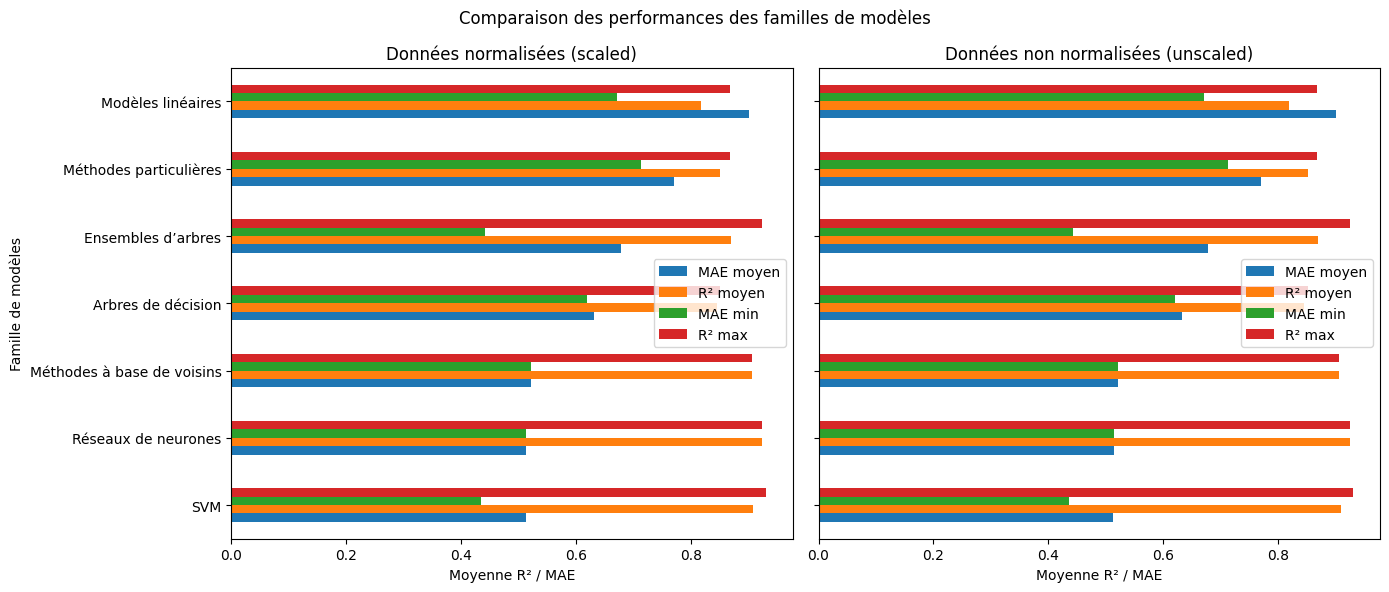

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# sélectionner la moyenne
scaled_plot = category_performance_scaled[[('MAE','mean'), ('r2_score','mean'), ('MAE','min'), ('r2_score','max')]]
unscaled_plot = category_performance_unscaled[[('MAE','mean'), ('r2_score','mean'), ('MAE','min'), ('r2_score','max')]]

# renommer les colonnes pour un affichage plus propre
scaled_plot.columns = ['MAE moyen', 'R² moyen', 'MAE min', 'R² max']
unscaled_plot.columns = ['MAE moyen', 'R² moyen', 'MAE min', 'R² max']

# graphique scaled
scaled_plot.plot(kind='barh', ax=axes[0])
axes[0].set_title('Données normalisées (scaled)')
axes[0].set_xlabel('Moyenne R² / MAE')
axes[0].set_ylabel('Famille de modèles')

# graphique unscaled
unscaled_plot.plot(kind='barh', ax=axes[1])
axes[1].set_title('Données non normalisées (unscaled)')
axes[1].set_xlabel('Moyenne R² / MAE')

plt.suptitle('Comparaison des performances des familles de modèles')

plt.tight_layout()
plt.show()

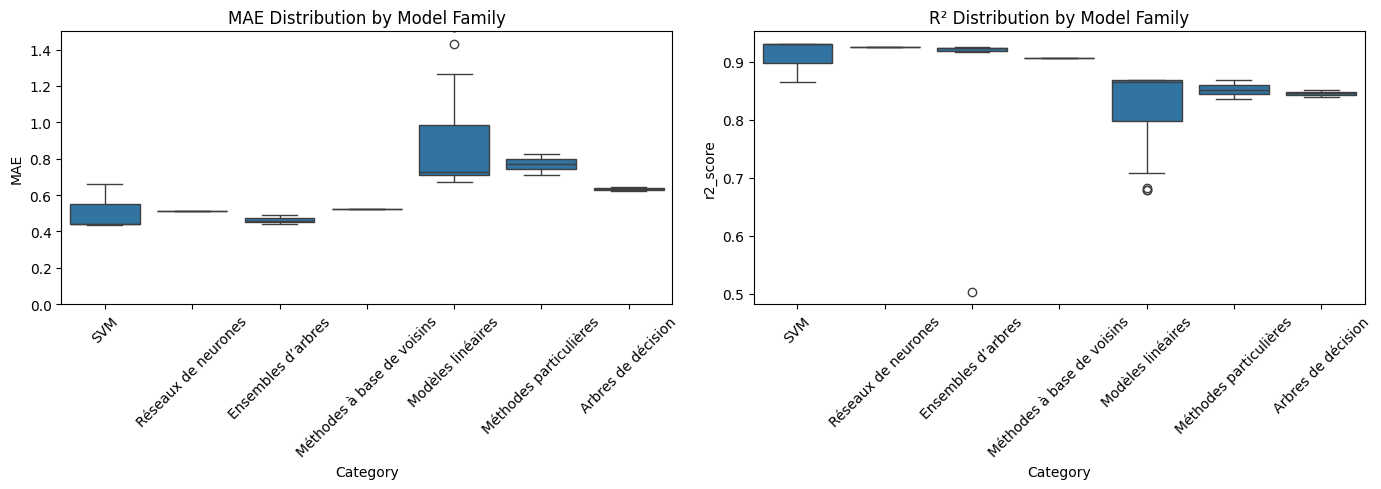

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='Category', 
            y='MAE', 
            data=models_df.loc[models_df.scaling_mode == 'scaled'], 
            ax=axes[0])
axes[0].set_title("MAE Distribution by Model Family")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1.5)

sns.boxplot(x='Category', 
            y='r2_score', 
            data=models_df.loc[models_df.scaling_mode == 'scaled'], 
            ax=axes[1])
axes[1].set_title("R² Distribution by Model Family")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## LGBMRegressor

In [9]:

def variables_importantes(model_class, X_train, y_train):
    """Calcule l'importance des variables pour un modèle donné."""

    # Instanciation du modèle
    model = model_class(random_state=42, n_jobs=-1)

    # Entraînement
    model.fit(X_train, y_train)

    # Récupération des importances
    importance = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    return importance

importance_lgbm = variables_importantes(LGBMRegressor, X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9024
[LightGBM] [Info] Number of data points in the train set: 52600, number of used features: 43
[LightGBM] [Info] Start training from score 2.403622


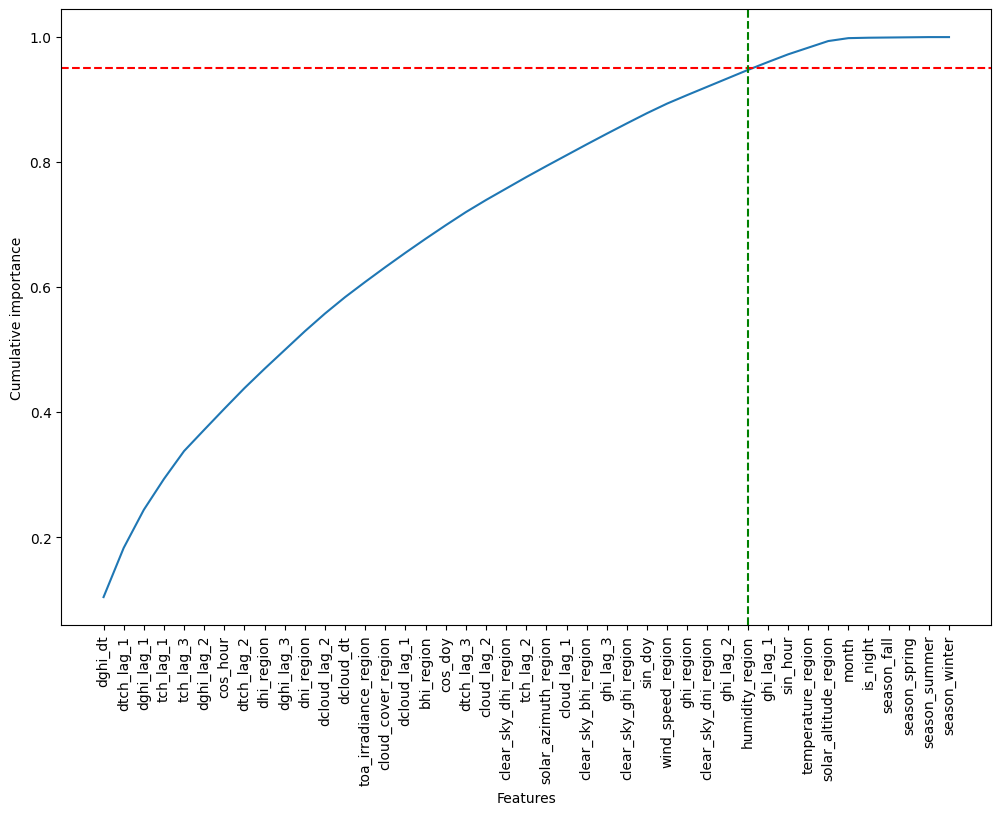

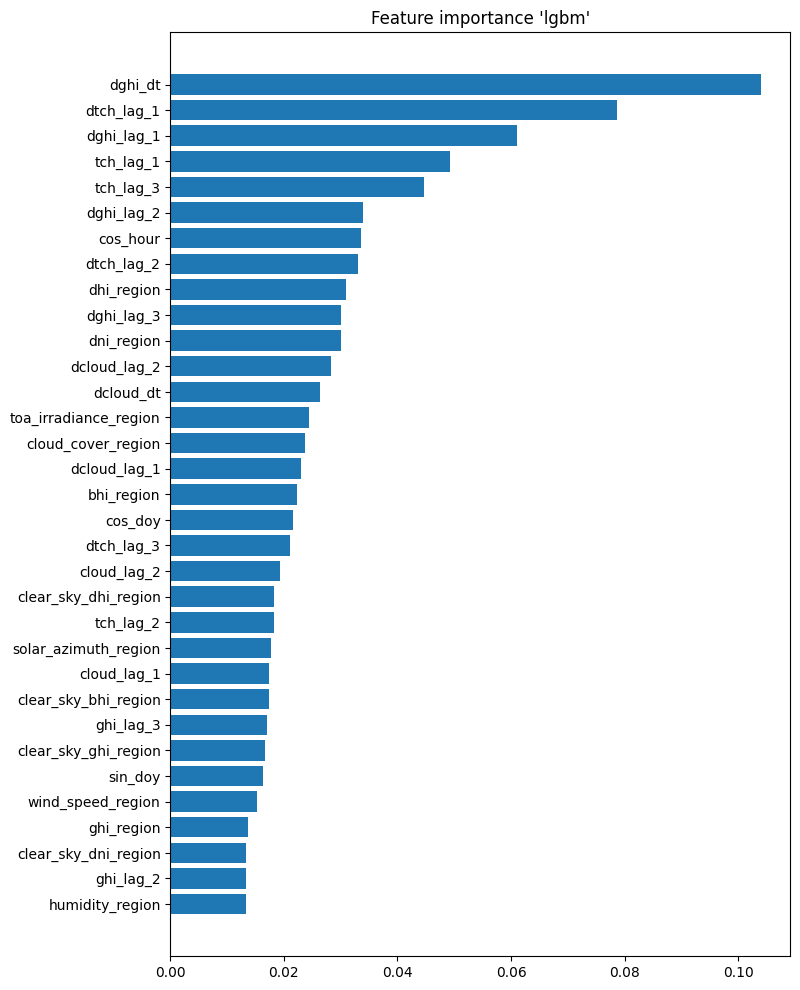

In [10]:
# Calcul de l'importance LGBM
importance_lgbm = importance_lgbm.sort_values(ascending=False)

# Calcul de l'importance cumulée normalisée
cum_importance_lgbm = importance_lgbm.cumsum() / importance_lgbm.sum()

# Sélection des variables expliquant jusqu'à 95% de l'importance
selected_features_lgbm = cum_importance_lgbm[cum_importance_lgbm <= 0.95].index

# Identification de la variable correspondant approximativement au seuil
index_threshold = cum_importance_lgbm[cum_importance_lgbm.round(2) == 0.95].index[0]

# Visualisation de l'importance cumulée des variables
plt.figure(figsize=(12,8))
plt.plot(cum_importance_lgbm.index, cum_importance_lgbm)
plt.axhline(0.95, color='red', linestyle='--')
plt.axvline(index_threshold, color='green', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.show()

# Visualisation de l'importance des variables sélectionnées
plt.figure(figsize=(8,12))
plt.barh(selected_features_lgbm, importance_lgbm[selected_features_lgbm]/importance_lgbm.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'lgbm'")
plt.show()


| Paramètre             | Explication                                                                                                                                                                                                        |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `n_estimators`        | Nombre d’arbres de boosting (itérations). Un plus grand nombre d’arbres améliore généralement les performances mais augmente le temps d’entraînement et le risque de surapprentissage (overfitting).               |
| `learning_rate`       | Taille du pas utilisée lors de la mise à jour des poids du modèle pendant le boosting. Des valeurs petites ralentissent l’apprentissage mais améliorent souvent la capacité de généralisation.                     |
| `num_leaves`          | Nombre maximal de feuilles par arbre. Des valeurs plus grandes permettent au modèle de capturer des relations plus complexes mais peuvent conduire au surapprentissage.                                            |
| `max_depth`           | Profondeur maximale de chaque arbre. `-1` signifie qu’il n’y a pas de limite. Limiter la profondeur aide à contrôler le surapprentissage et à réduire la complexité du modèle.                                     |
| `min_child_samples`   | Nombre minimum d’échantillons requis dans un nœud feuille. Des valeurs plus élevées rendent le modèle plus conservateur et réduisent le surapprentissage.                                                          |
| `subsample`           | Fraction des échantillons d’entraînement utilisée pour construire chaque arbre (échantillonnage des lignes). Des valeurs inférieures à 1 introduisent de l’aléatoire et améliorent la généralisation.              |
| `colsample_bytree`    | Fraction des variables (features) sélectionnées aléatoirement pour chaque arbre (échantillonnage des variables). Cela aide à réduire la corrélation entre les arbres et limite le surapprentissage.                |
| `reg_alpha`           | Terme de régularisation L1 appliqué aux poids des feuilles. Il favorise la parcimonie et réduit le surapprentissage en pénalisant les poids trop élevés.                                                           |
| `reg_lambda`          | Terme de régularisation L2 appliqué aux poids des feuilles. Il stabilise le modèle en pénalisant les coefficients trop grands et améliore la généralisation.                                                       |
| `estimator`           | Modèle d’apprentissage automatique à optimiser (ici c'est la régression LightGBM).                                                                                                                                              |
| `param_distributions` | Dictionnaire définissant l’espace de recherche des hyperparamètres.                                                                                                                                                |
| `n_iter`              | Nombre de combinaisons de paramètres testées aléatoirement. Des valeurs plus élevées explorent davantage de configurations mais augmentent le temps de calcul.                                                     |
| `scoring`             | Métrique d’évaluation utilisée pendant la validation croisée. `"neg_mean_absolute_error"` est utilisé car sklearn maximise les scores ; le signe négatif permet de transformer le MAE en problème de maximisation. |
| `cv`                  | Stratégie de validation croisée. Ici `TimeSeriesSplit` garantit que l’entraînement se fait sur des données passées et la validation sur des données futures.                                                       |
| `refit`               | Si `True`, le meilleur modèle trouvé pendant la validation croisée est réentraîné sur l’ensemble complet des données d’entraînement.                                                                               |


In [12]:
# Création d'une validation croisée adaptée aux séries temporelles (5 splits)
tscv = TimeSeriesSplit(n_splits=5)

# Initialisation du modèle LightGBM pour la régression
lgbm = LGBMRegressor(n_jobs=-1, random_state=42)

# Définition de l'espace de recherche des hyperparamètres
param_dist_lgbm = {
    "n_estimators": [500, 800, 1000, 1500],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "num_leaves": [15, 31, 63, 127, 255],
    "max_depth": [-1, 5, 7, 10],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.0, 0.01, 0.1, 1.0, 5.0]
}

# Recherche aléatoire des meilleurs hyperparamètres avec validation croisée
search_lgbm = RandomizedSearchCV(
    estimator=lgbm,                     
    param_distributions=param_dist_lgbm,# grille d'hyperparamètres
    n_iter=150,                         # nombre de combinaisons testées, donc on aura 150*5 = 750 fits
    scoring="neg_mean_absolute_error", 
    cv=tscv,                          
    verbose=2,                          
    random_state=42,
    n_jobs=-1,                         
    refit=True 
)

# Entraînement de la recherche d'hyperparamètres
search_lgbm.fit(X_train[selected_features_lgbm], y_train)

# Affichage des meilleurs paramètres trouvés
print("Meilleurs paramètres LightGBM :")
print(search_lgbm.best_params_)

# Affichage du meilleur score MAE (on remet le signe positif)
print("Meilleur score CV (MAE) :", -search_lgbm.best_score_)

with open('search_lgbm_pickle.pkl', mode='bw') as f:
    pickle.dump(search_lgbm, f)
    
with open("search_lgbm_pickle.pkl", "rb") as f:
    search_lgbm = pickle.load(f)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8199
[LightGBM] [Info] Number of data points in the train set: 52600, number of used features: 33
[LightGBM] [Info] Start training from score 2.403622
Meilleurs paramètres LightGBM :
{'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.01, 'num_leaves': 255, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Meilleur score CV (MAE) : 0.419808079879329


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8199
[LightGBM] [Info] Number of data points in the train set: 70120, number of used features: 33
[LightGBM] [Info] Start training from score 2.441441
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

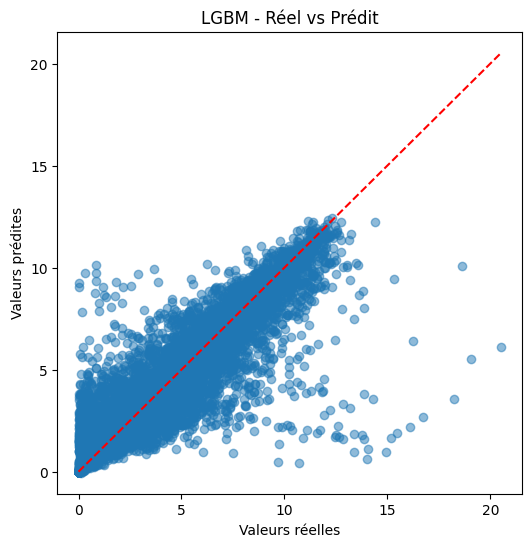

In [37]:

# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_lgbm = pd.concat([X_train[selected_features_lgbm], X_valid[selected_features_lgbm]])
y_train_lgbm = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_lgbm = X_test[selected_features_lgbm].copy()
y_test_lgbm = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params = search_lgbm.best_params_
params = best_params.copy()
params['max_depth'] = 9
params['subsample'] = 0.8

# Initialisation du modèle LightGBM de régression
final_lgbm = LGBMRegressor(
    n_jobs=-1,  
    random_state=42,
    bagging_freq=1,
    **params
)

# Entraînement du modèle
final_lgbm.fit(X_train_lgbm, y_train_lgbm)

# Prédiction sur le jeu de test/train
y_pred_lgbm = final_lgbm.predict(X_test_lgbm)
y_pred_train_lgbm = final_lgbm.predict(X_train_lgbm)

# Évaluation
mae_lgbm = mean_absolute_error(y_test_lgbm, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_lgbm, y_pred_lgbm))
r2_test_lgbm = r2_score(y_test_lgbm, y_pred_lgbm)
r2_train_lgbm = r2_score(y_train_lgbm, y_pred_train_lgbm)
mae_rel_lgbm = mae_lgbm / y_test_lgbm.mean() * 100

print("\n--- Résultats LGBM ---")
print("MAE         :", mae_lgbm)
print(f"MAE relatif : {round(mae_rel_lgbm, 3)}%")
print("RMSE        :", rmse_lgbm)
print("R² train    :", r2_train_lgbm)
print("R² test     :", r2_test_lgbm)

plt.figure(figsize=(6,6))
plt.scatter(y_test_lgbm, y_pred_lgbm, alpha=0.5)
plt.plot([y_test_lgbm.min(), y_test_lgbm.max()],
         [y_test_lgbm.min(), y_test_lgbm.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("LGBM - Réel vs Prédit")
plt.show()

## XGBRegressor

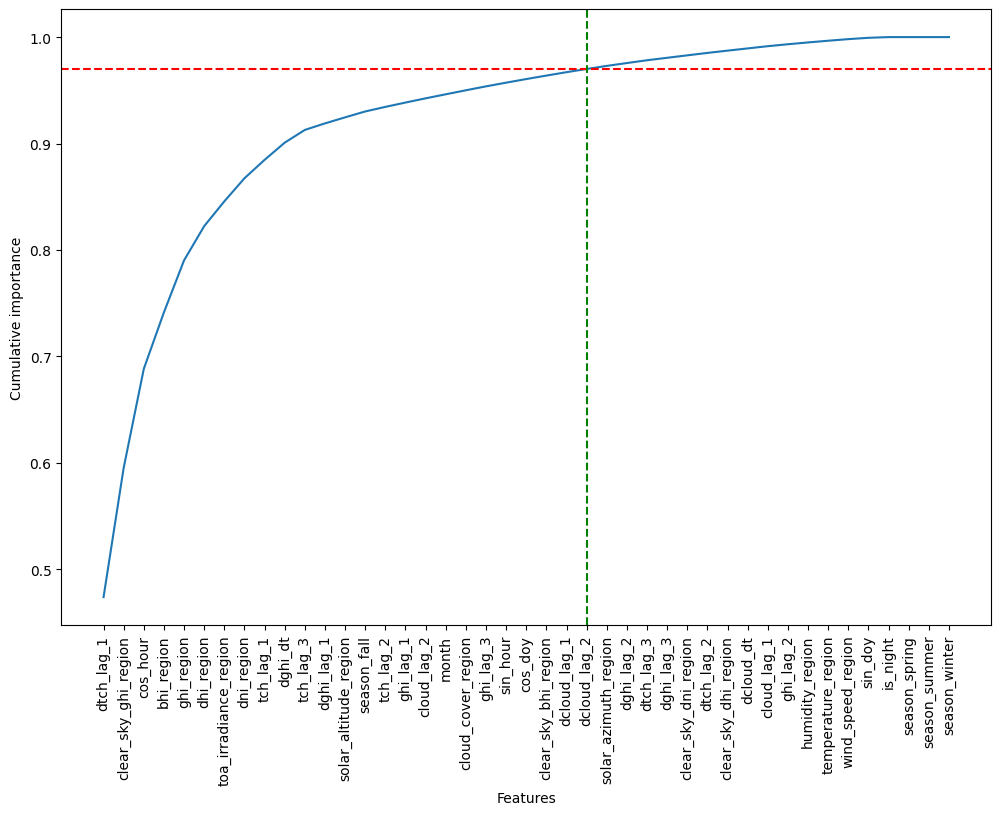

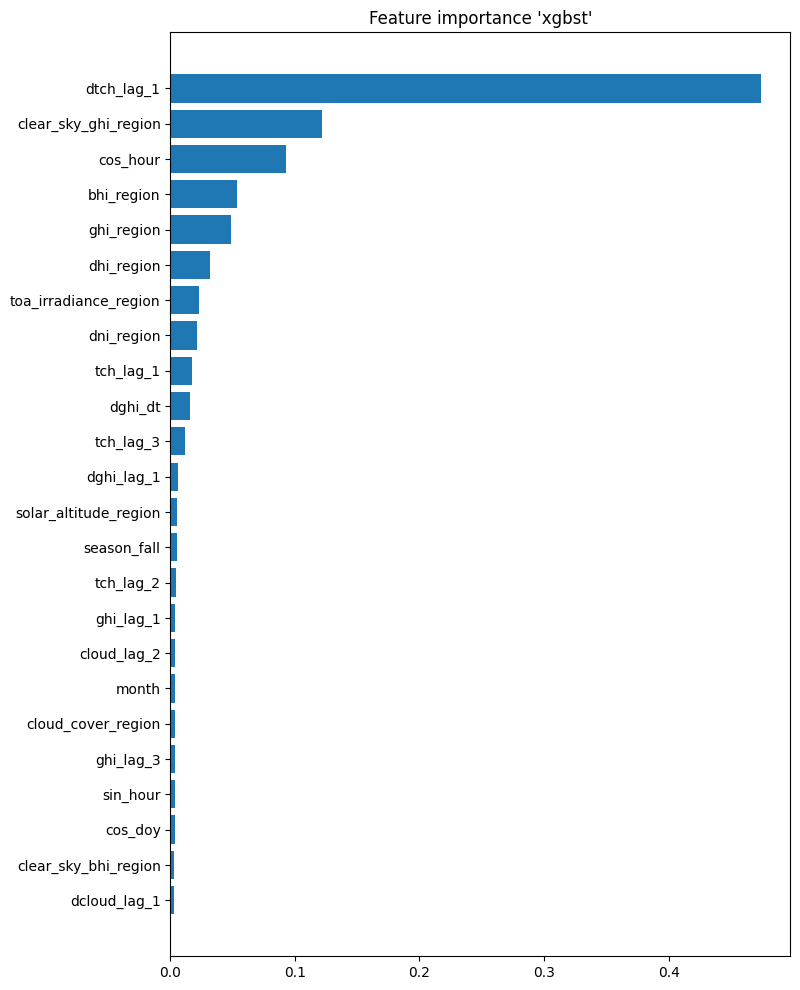

In [41]:
# Calcul et tri de l'importance des variables
importance_xgb = variables_importantes(XGBRegressor, X_train, y_train).sort_values(ascending=False)
threshold = 0.97

# Calcul de l'importance cumulée normalisée
cum_importance_xgb = importance_xgb.cumsum() / importance_xgb.sum()

# Sélection des variables expliquant jusqu'à 95% de l'importance
selected_features_xgb = cum_importance_xgb[cum_importance_xgb <= threshold].index

# Identification de la variable correspondant approximativement au seuil
index_threshold = cum_importance_xgb[cum_importance_xgb.round(2) == threshold].index[1]

# Visualisation de l'importance cumulée des variables
plt.figure(figsize=(12,8))
plt.plot(cum_importance_xgb.index, cum_importance_xgb)
plt.axhline(threshold, color='red', linestyle='--')
plt.axvline(index_threshold, color='green', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.show()

# Visualisation de l'importance des variables sélectionnées
plt.figure(figsize=(8,12))
plt.barh(selected_features_xgb, importance_xgb[selected_features_xgb]/importance_xgb.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'xgbst'")
plt.show()

| Paramètre             | Explication                                                                                                                                                                           |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `n_estimators`        | Nombre d’arbres de boosting construits successivement. Une grande valeur peut améliorer les performances, mais augmente le temps de calcul et le risque de surapprentissage.          |
| `learning_rate`       | Taux d’apprentissage appliqué à la contribution de chaque arbre. Une petite valeur rend l’apprentissage plus progressif, mais nécessite souvent plus d’arbres.                        |
| `max_depth`           | Profondeur maximale de chaque arbre. Des arbres plus profonds capturent des relations plus complexes, mais peuvent surajuster les données.                                            |
| `min_child_weight`    | Poids minimal requis dans un nœud feuille pour autoriser une nouvelle division. Une valeur élevée rend le modèle plus conservateur.                                                   |
| `subsample`           | Fraction des observations d’entraînement utilisée pour construire chaque arbre. Une valeur inférieure à 1 peut aider à réduire le surapprentissage.                                   |
| `colsample_bytree`    | Fraction des variables utilisée pour construire chaque arbre. Cela permet de diversifier les arbres et de limiter le surapprentissage.                                                |
| `gamma`               | Gain minimal requis pour effectuer une nouvelle division dans un arbre. Plus `gamma` est grand, plus le modèle devient prudent dans les divisions.                                    |
| `reg_alpha`           | Régularisation L1 appliquée aux poids du modèle. Elle peut forcer certains poids à devenir nuls et ainsi rendre le modèle plus parcimonieux.                                          |
| `reg_lambda`          | Régularisation L2 appliquée aux poids du modèle. Elle pénalise les poids trop grands et aide à stabiliser le modèle.                                                                  |
| `tree_method`         | Méthode de construction des arbres. Ici `hist` utilise un algorithme basé sur des histogrammes, souvent plus rapide et efficace sur de grands jeux de données.                        |
| `max_bin`             | Nombre maximal d’intervalles utilisés pour discrétiser les variables continues avec `tree_method="hist"`. Une valeur plus grande peut améliorer la précision mais ralentir le calcul. |
| `n_iter`              | Nombre de combinaisons de paramètres testées aléatoirement parmi tout l’espace possible.                                                                                              |
| `scoring`             | Métrique utilisée pour comparer les modèles pendant la validation croisée. Ici `neg_mean_absolute_error` correspond à la MAE négative.                                                |
| `cv`                  | Méthode de validation croisée utilisée, ici `TimeSeriesSplit`, adaptée aux séries temporelles.                                                                                        |
| `refit`               | Si `True`, le meilleur modèle trouvé est réentraîné automatiquement sur toutes les données d’entraînement après la recherche.                                                         |


In [76]:
# Validation croisée adaptée aux séries temporelles
tscv = TimeSeriesSplit(n_splits=5)

# Initialisation du modèle XGBoost
xgb = XGBRegressor(
    n_jobs=-1,
    random_state=42
)

# Espace de recherche des hyperparamètres
param_dist_xgb = {
    "n_estimators": [1000, 2000, 2500],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "max_depth": [4, 7, 10, 13],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0.01, 0.1, 1.0],
    "reg_lambda": [0.01, 0.1, 1.0, 5.0],
    "tree_method": ["hist"],
    "max_bin": [256, 512]
}

# Recherche aléatoire des hyperparamètres
search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=150,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Entraînement
search_xgb.fit(X_train[selected_features_xgb], y_train)

# Meilleurs paramètres
print("Meilleurs paramètres XGBoost :")
print(search_xgb.best_params_)

# Meilleur score
print("Meilleur score CV (MAE) :", -search_xgb.best_score_)

# Sauvegarde de l'objet search_xgb dans un fichier pickle
with open('search_xgb_pickle.pkl', 'wb') as f:
    pickle.dump(search_xgb, f)

# Chargement de l'objet search_xgb depuis le fichier pickle
with open('search_xgb_pickle.pkl', 'rb') as f:
    search_xgb = pickle.load(f)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Meilleurs paramètres XGBoost :
{'tree_method': 'hist', 'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 2500, 'min_child_weight': 5, 'max_depth': 10, 'max_bin': 512, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}
Meilleur score CV (MAE) : 0.41344676505566824



--- Résultats XGBoost ---
MAE         : 0.4418316435106212
MAE relatif : 18.358%
RMSE        : 1.043138194428154
R² train    : 0.991524557220493
R² test     : 0.8990134234787197


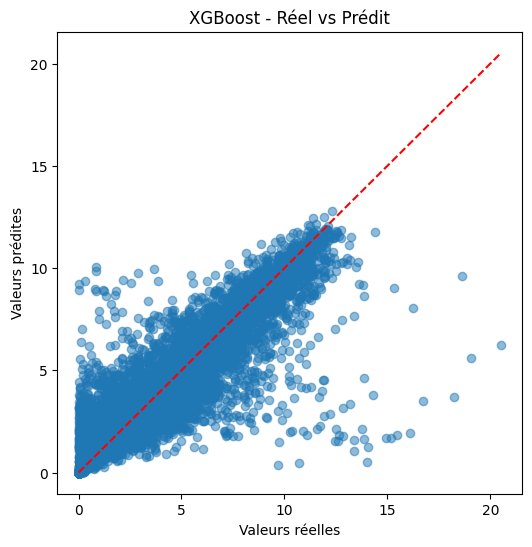

In [78]:

# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_xgb = pd.concat([X_train[selected_features_xgb], X_valid[selected_features_xgb]])
y_train_xgb = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_xgb = X_test[selected_features_xgb].copy()
y_test_xgb = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params = search_xgb.best_params_

# Initialisation du modèle XGBoost de régression
final_xgb = XGBRegressor(
    eval_metric="mae",
    n_jobs=-1,
    random_state=42,
    **best_params
)

# Entraînement du modèle
final_xgb.fit(X_train_xgb, y_train_xgb)

# Prédiction sur le jeu de test/train
y_pred_xgb = final_xgb.predict(X_test_xgb)
y_pred_train_xgb = final_xgb.predict(X_train_xgb)

# Évaluation
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
r2_test_xgb = r2_score(y_test_xgb, y_pred_xgb)
r2_train_xgb = r2_score(y_train_xgb, y_pred_train_xgb)
mae_rel_xgb = mae_xgb / y_test_xgb.mean() * 100

print("\n--- Résultats XGBoost ---")
print("MAE         :", mae_xgb)
print(f"MAE relatif : {round(mae_rel_xgb, 3)}%")
print("RMSE        :", rmse_xgb)
print("R² train    :", r2_train_xgb)
print("R² test     :", r2_test_xgb)

plt.figure(figsize=(6,6))
plt.scatter(y_test_xgb, y_pred_xgb, alpha=0.5)
plt.plot([y_test_xgb.min(), y_test_xgb.max()],
         [y_test_xgb.min(), y_test_xgb.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("XGBoost - Réel vs Prédit")
plt.show()

# ExtraTreesRegressor

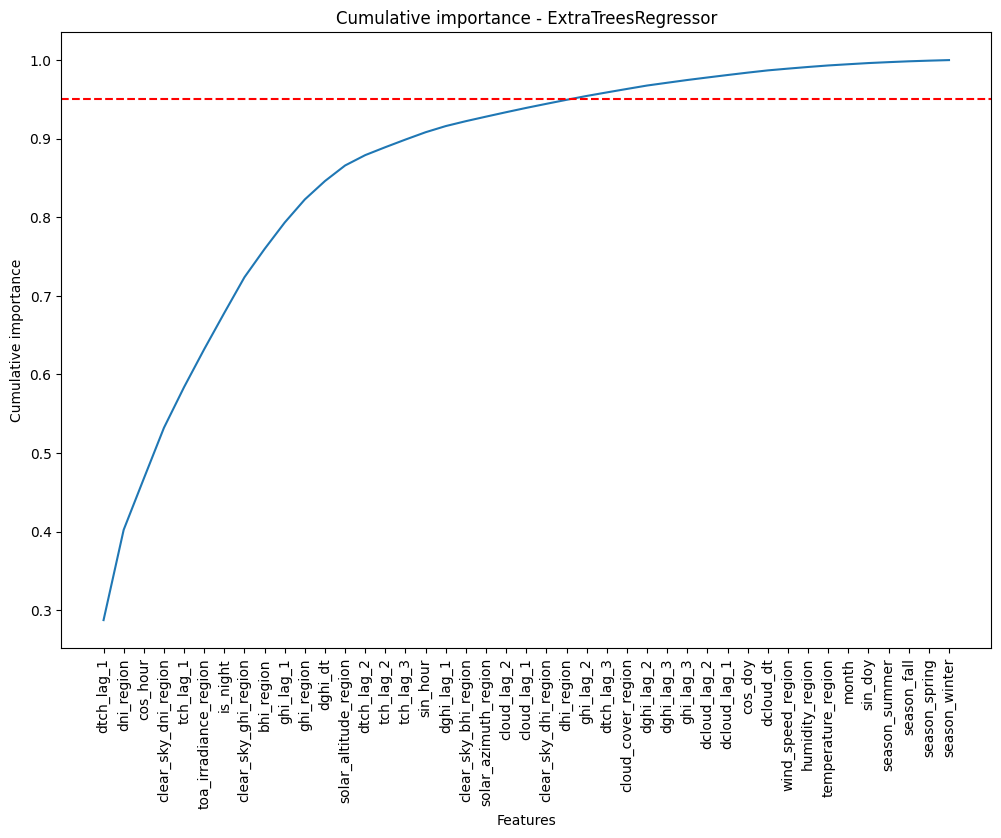

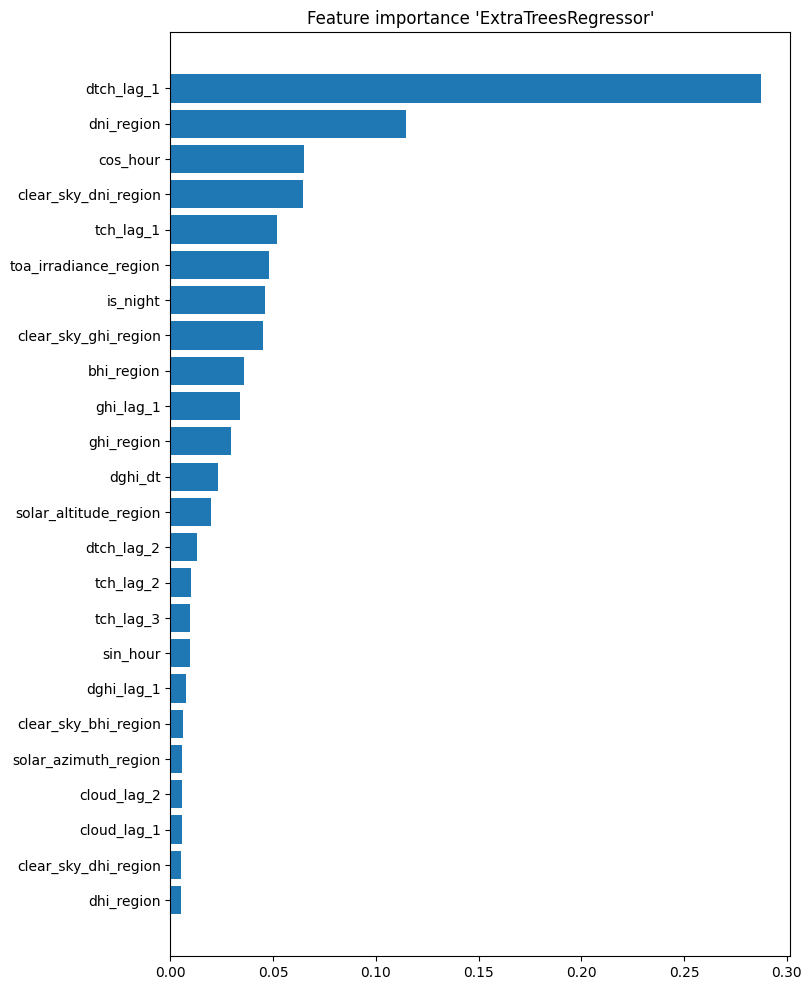

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Meilleurs paramètres ExtraTreesRegressor :
{'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 20, 'bootstrap': False}
Meilleur score CV (MAE) : 0.4189199193259526


In [16]:

importance_etr = variables_importantes(ExtraTreesRegressor, X_train, y_train)

importance_etr = importance_etr.sort_values(ascending=False)

cum_importance_etr = importance_etr.cumsum() / importance_etr.sum()

selected_features_etr = cum_importance_etr[cum_importance_etr <= 0.95].index

plt.figure(figsize=(12,8))
plt.plot(cum_importance_etr.index, cum_importance_etr)
plt.axhline(0.95, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.title("Cumulative importance - ExtraTreesRegressor")
plt.show()

plt.figure(figsize=(8,12))
plt.barh(selected_features_etr, importance_etr[selected_features_etr] / importance_etr.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'ExtraTreesRegressor'")
plt.show()

# Création d'une validation croisée adaptée aux séries temporelles
tscv = TimeSeriesSplit(n_splits=5)

# Initialisation du modèle ExtraTreesRegressor
etr = ExtraTreesRegressor(random_state=42, n_jobs=-1)

# Définition de l'espace de recherche des hyperparamètres
param_dist_etr = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
    "bootstrap": [False, True]
}

# Recherche aléatoire des meilleurs hyperparamètres
search_etr = RandomizedSearchCV(
    estimator=etr,
    param_distributions=param_dist_etr,
    n_iter=150,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Entraînement
search_etr.fit(X_train[selected_features_etr], y_train)

# Affichage des meilleurs paramètres trouvés
print("Meilleurs paramètres ExtraTreesRegressor :")
print(search_etr.best_params_)

# Affichage du meilleur score MAE
print("Meilleur score CV (MAE) :", -search_etr.best_score_)

with open("search_etr_pickle.pkl", mode="bw") as f:
    pickle.dump(search_etr, f)

with open("search_etr_pickle.pkl", "rb") as f:
    search_etr = pickle.load(f)


--- Résultats ExtraTreesRegressor ---
MAE         : 0.4499775429245068
MAE relatif : 18.696%
RMSE        : 1.0585258893014673
R² train    : 0.9904508944948077
R² test     : 0.8960120722336706


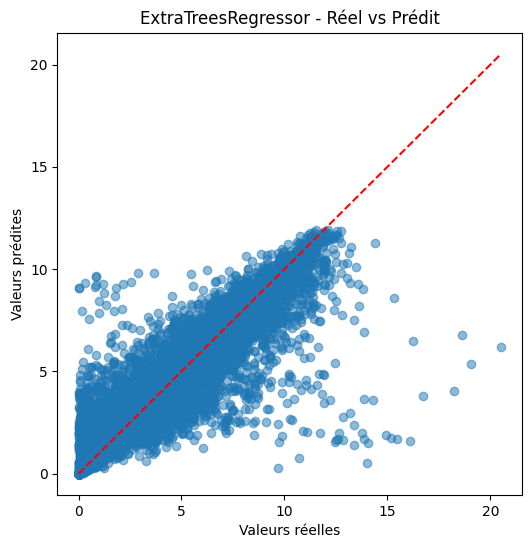

In [17]:

# # Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_etr = pd.concat([X_train[selected_features_etr], X_valid[selected_features_etr]])
y_train_etr = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_etr = X_test[selected_features_etr].copy()
y_test_etr = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params_etr = search_etr.best_params_

# Initialisation du modèle Extra Trees de régression
final_etr = ExtraTreesRegressor(
    random_state=42, 
    n_jobs=-1, 
    **best_params_etr
)

# Entraînement du modèle
final_etr.fit(X_train_etr, y_train_etr)

# Prédiction sur le jeu de test/train
y_pred_etr = final_etr.predict(X_test_etr)
y_pred_train_etr = final_etr.predict(X_train_etr)

# Évaluation
mae_etr = mean_absolute_error(y_test_etr, y_pred_etr)
rmse_etr = np.sqrt(mean_squared_error(y_test_etr, y_pred_etr))
r2_test_etr = r2_score(y_test_etr, y_pred_etr)
r2_train_etr = r2_score(y_train_etr, y_pred_train_etr)
mae_rel_etr = mae_etr / y_test_etr.mean() * 100

print("\n--- Résultats ExtraTreesRegressor ---")
print("MAE         :", mae_etr)
print(f"MAE relatif : {round(mae_rel_etr, 3)}%")
print("RMSE        :", rmse_etr)
print("R² train    :", r2_train_etr)
print("R² test     :", r2_test_etr)

plt.figure(figsize=(6,6))
plt.scatter(y_test_etr, y_pred_etr, alpha=0.5)
plt.plot([y_test_etr.min(), y_test_etr.max()],
         [y_test_etr.min(), y_test_xgb.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTreesRegressor - Réel vs Prédit")
plt.show()

# RandomForrestRegressor

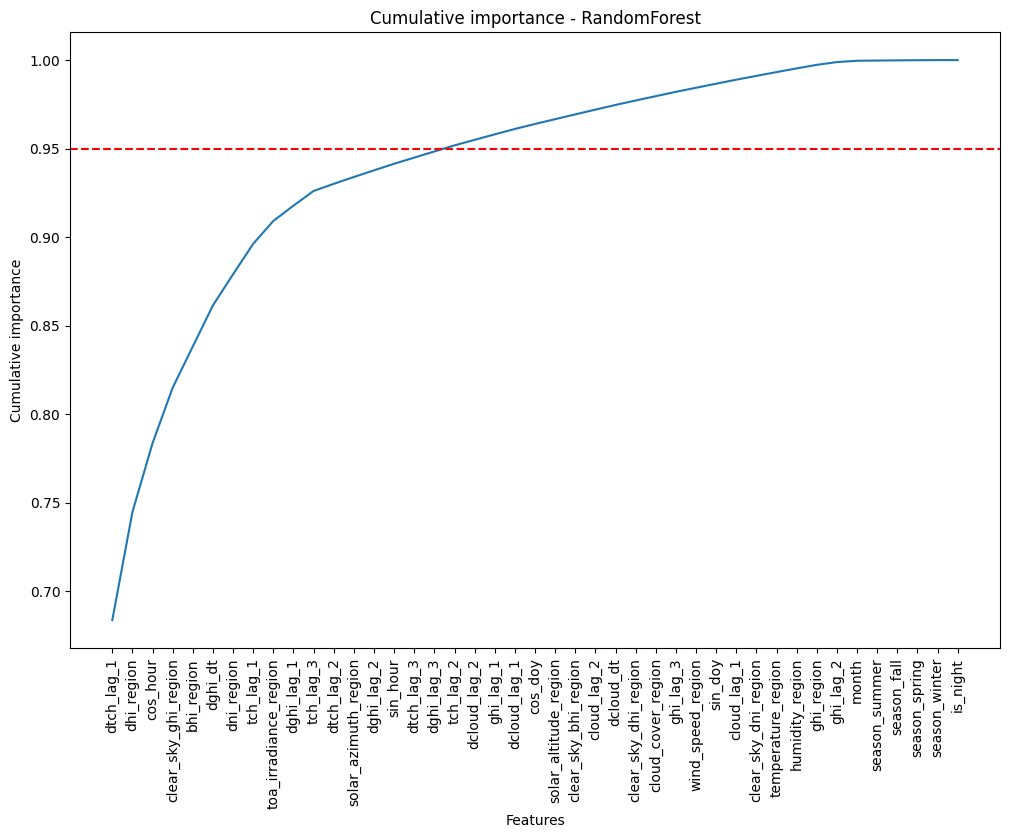

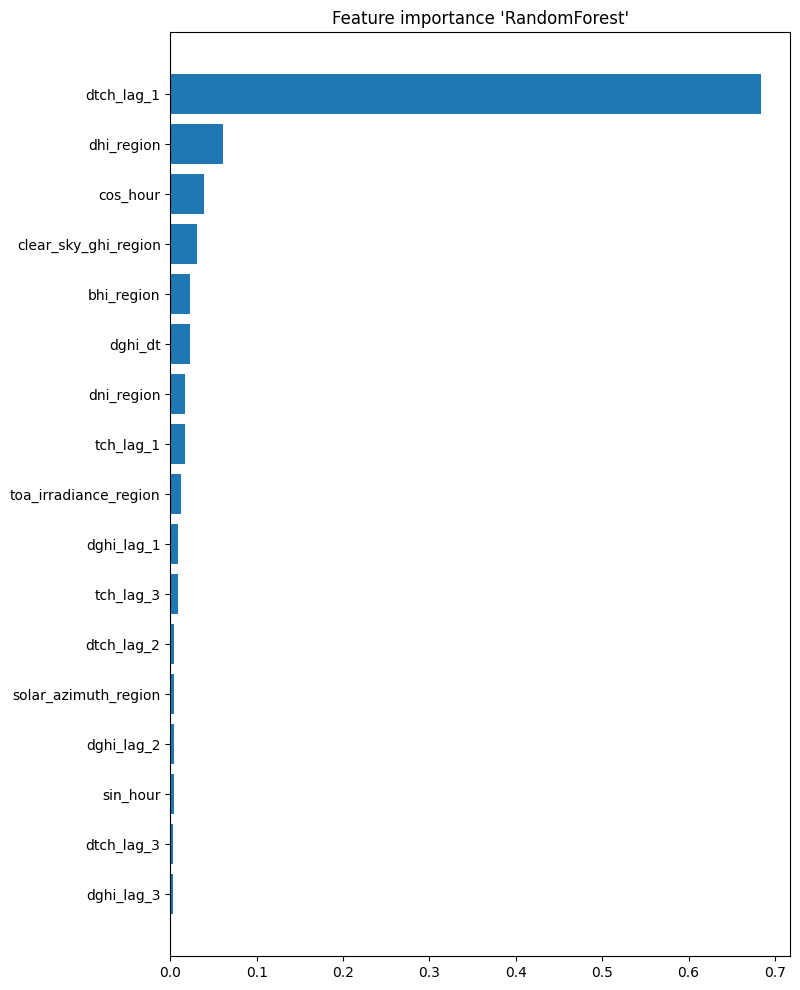

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Meilleurs paramètres RandomForest :
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None, 'bootstrap': True}
Meilleur score CV (MAE) : 0.4206574673543383


In [19]:

importance_rf = variables_importantes(RandomForestRegressor, X_train, y_train)

importance_rf = importance_rf.sort_values(ascending=False)

cum_importance_rf = importance_rf.cumsum() / importance_rf.sum()

selected_features_rf = cum_importance_rf[cum_importance_rf <= 0.95].index

# sécurité
if len(selected_features_rf) == 0:
    selected_features_rf = importance_rf.index[:1]


plt.figure(figsize=(12,8))
plt.plot(cum_importance_rf.index, cum_importance_rf)
plt.axhline(0.95, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.title("Cumulative importance - RandomForest")
plt.show()


plt.figure(figsize=(8,12))
plt.barh(
    selected_features_rf,
    importance_rf[selected_features_rf] / importance_rf.sum()
)
plt.gca().invert_yaxis()
plt.title("Feature importance 'RandomForest'")
plt.show()


# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)

# Modèle RandomForest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Espace de recherche
param_dist_rf = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
    "bootstrap": [True, False]
}


search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=150,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# entraînement
search_rf.fit(X_train[selected_features_rf], y_train)


print("Meilleurs paramètres RandomForest :")
print(search_rf.best_params_)

print("Meilleur score CV (MAE) :", -search_rf.best_score_)


with open("search_rf_pickle.pkl", mode="bw") as f:
    pickle.dump(search_rf, f)

with open("search_rf_pickle.pkl", "rb") as f:
    search_rf = pickle.load(f)


--- Résultats RandomForrestRegressor ---
MAE         : 0.4556993827056305
MAE relatif : 18.934%
RMSE        : 1.0653833514509021
R² train    : 0.984453921885419
R² test     : 0.8946603752999339


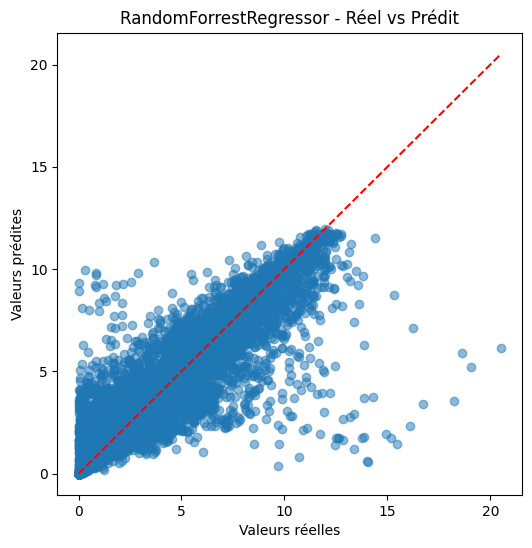

In [23]:
# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_rf = pd.concat([X_train[selected_features_rf], X_valid[selected_features_rf]])
y_train_rf = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_rf = X_test[selected_features_rf].copy()
y_test_rf = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params_rf = search_rf.best_params_

# Initialisation du modèle Random Forest de régression
final_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params_rf
)

# Entraînement du modèle
final_rf.fit(X_train_rf, y_train_rf)

# Prédiction sur le jeu de test/train
y_pred_rf = final_rf.predict(X_test_rf)
y_pred_train_rf = final_rf.predict(X_train_rf)

# Évaluation
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_test_rf = r2_score(y_test_rf, y_pred_rf)
r2_train_rf = r2_score(y_train_rf, y_pred_train_rf)
mae_rel_rf = mae_rf / y_test_rf.mean() * 100

print("\n--- Résultats RandomForrestRegressor ---")
print("MAE         :", mae_rf)
print(f"MAE relatif : {round(mae_rel_rf, 3)}%")
print("RMSE        :", rmse_rf)
print("R² train    :", r2_train_rf)
print("R² test     :", r2_test_rf)

plt.figure(figsize=(6,6))
plt.scatter(y_test_rf, y_pred_rf, alpha=0.5)
plt.plot([y_test_rf.min(), y_test_rf.max()],
         [y_test_rf.min(), y_test_xgb.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("RandomForrestRegressor - Réel vs Prédit")
plt.show()

In [ ]:
def variables_importantes_svr(model_class, X_train, y_train, random_state=42):
    """Calcule l'importance des variables pour un modèle SVR donné."""

    # Instanciation du modèle
    model = model_class()

    # Entraînement
    model.fit(X_train, y_train)

    # Importance par permutation
    result = permutation_importance(
        model,
        X_train,
        y_train,
        n_repeats=10,
        random_state=random_state,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    importance = pd.Series(
        result.importances_mean,
        index=X_train.columns
    ).sort_values(ascending=False)

    return importance

importance_svr = variables_importantes_svr(SVR, X_train_scaled, y_train)

importance_svr = importance_svr.sort_values(ascending=False)

# garder seulement les importances positives
importance_svr = importance_svr[importance_svr > 0]

cum_importance_svr = importance_svr.cumsum() / importance_svr.sum()

selected_features_svr = cum_importance_svr[cum_importance_svr <= 0.95].index


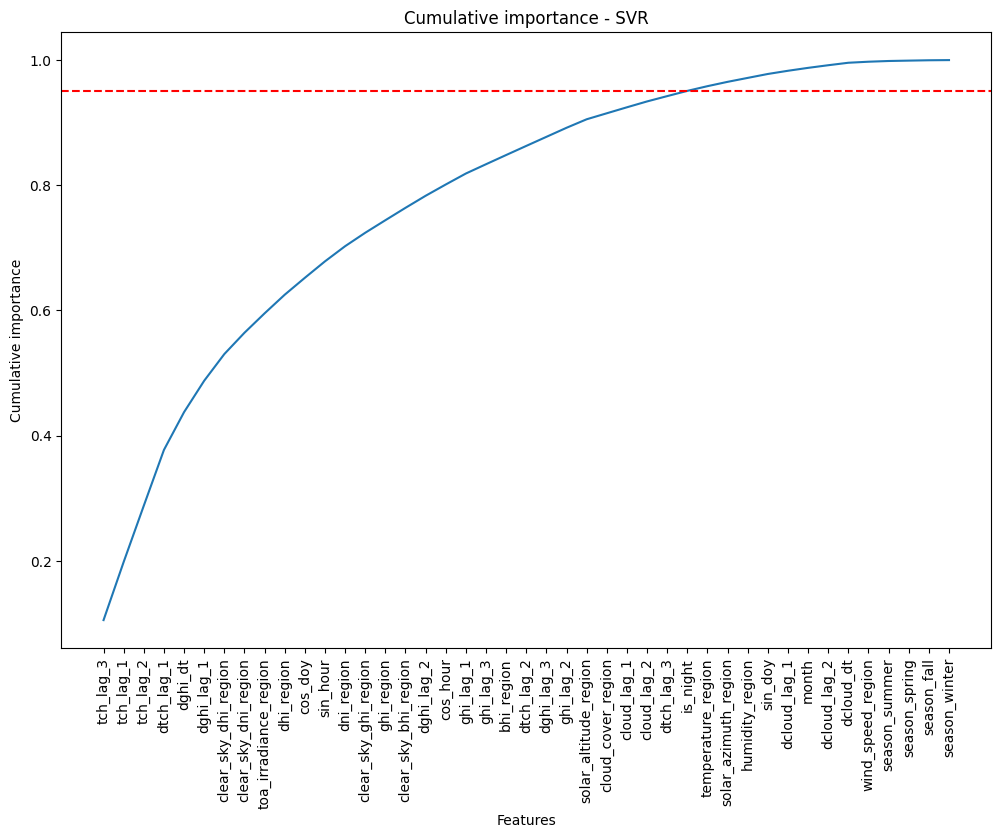

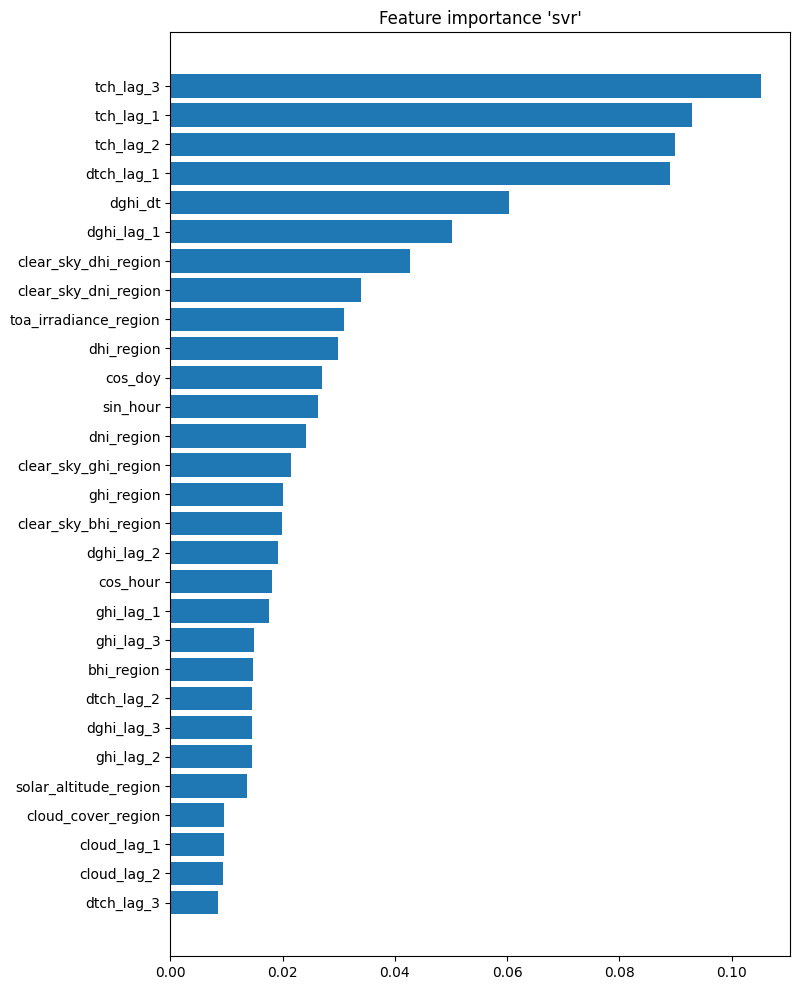

In [57]:
plt.figure(figsize=(12,8))
plt.plot(cum_importance_svr.index, cum_importance_svr)
plt.axhline(0.95, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.title("Cumulative importance - SVR")
plt.show()

plt.figure(figsize=(8,12))
plt.barh(selected_features_svr, importance_svr[selected_features_svr]/importance_svr.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'svr'")
plt.show()


In [61]:
# selected_features_svr = ['tch_lag_3', 'tch_lag_1', 'tch_lag_2', 'dtch_lag_1', 'dghi_dt',
#        'dghi_lag_1', 'clear_sky_dhi_region', 'clear_sky_dni_region',
#        'toa_irradiance_region', 'dhi_region', 'cos_doy', 'sin_hour',
#        'dni_region', 'clear_sky_ghi_region', 'ghi_region',
#        'clear_sky_bhi_region', 'dghi_lag_2', 'cos_hour', 'ghi_lag_1',
#        'ghi_lag_3', 'bhi_region', 'dtch_lag_2', 'dghi_lag_3', 'ghi_lag_2',
#        'solar_altitude_region', 'cloud_cover_region', 'cloud_lag_1',
#        'cloud_lag_2', 'dtch_lag_3']

Index(['tch_lag_3', 'tch_lag_1', 'tch_lag_2', 'dtch_lag_1', 'dghi_dt',
       'dghi_lag_1', 'clear_sky_dhi_region', 'clear_sky_dni_region',
       'toa_irradiance_region', 'dhi_region', 'cos_doy', 'sin_hour',
       'dni_region', 'clear_sky_ghi_region', 'ghi_region',
       'clear_sky_bhi_region', 'dghi_lag_2', 'cos_hour', 'ghi_lag_1',
       'ghi_lag_3', 'bhi_region', 'dtch_lag_2', 'dghi_lag_3', 'ghi_lag_2',
       'solar_altitude_region', 'cloud_cover_region', 'cloud_lag_1',
       'cloud_lag_2', 'dtch_lag_3'],
      dtype='object')

| Paramètre | Explication                                                                                                                                                                                                                                                                                               |
| --------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `kernel`  | Fonction noyau utilisée pour transformer les données dans un espace de dimension plus élevée afin de modéliser des relations non linéaires. Ici `rbf` (Radial Basis Function) est très courant car il permet de capturer des relations complexes entre les variables.                                     |
| `C`       | Paramètre de régularisation qui contrôle le compromis entre la complexité du modèle et l’erreur d’entraînement. Une grande valeur de `C` cherche à minimiser l’erreur sur les données d’entraînement mais peut provoquer du surapprentissage, tandis qu’une petite valeur rend le modèle plus régularisé. |
| `epsilon` | Largeur de la **zone de tolérance** autour de la prédiction dans laquelle les erreurs ne sont pas pénalisées. Une valeur plus grande rend le modèle moins sensible aux petites erreurs et peut améliorer la généralisation.                                                                               |
| `gamma`   | Paramètre spécifique aux noyaux comme `rbf`. Il contrôle l’influence d’un point d’entraînement sur la prédiction. Une grande valeur signifie que l’influence est très locale (modèle plus complexe), tandis qu’une petite valeur rend l’influence plus globale (modèle plus lisse).                       |


In [67]:

# Validation croisée adaptée aux séries temporelles
tscv = TimeSeriesSplit(n_splits=5)

# Modèle SVR
svr = SVR(kernel='rbf', 
          gamma='scale')

# Espace de recherche réduit et raisonnable
param_dist_svr = {
    "C": [0.01, 0.1, 1, 10, 50],
    "epsilon": [0.001, 0.01, 0.05, 0.1, 0.2]
}

# Recherche aléatoire
search_svr = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist_svr,
    n_iter=25,                
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Entraînement
search_svr.fit(X_train_scaled[selected_features_svr], y_train)

# Résultats
print("Meilleurs paramètres SVR :")
print(search_svr.best_params_)

print("Meilleur score CV (MAE) :", -search_svr.best_score_)

# Sauvegarde
with open("search_svr_pickle.pkl", mode="bw") as f:
    pickle.dump(search_svr, f)

# Rechargement
with open("search_svr_pickle.pkl", "rb") as f:
    search_svr = pickle.load(f)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Meilleurs paramètres SVR :
{'epsilon': 0.001, 'C': 10}
Meilleur score CV (MAE) : 0.39465832557636227


In [81]:

# # Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_svr = pd.concat([X_train_scaled[selected_features_svr], X_valid_scaled[selected_features_svr]])
y_train_svr = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_svr = X_test_scaled[selected_features_svr].copy()
y_test_svr = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params = search_svr.best_params_

# Initialisation du modèle SVM de régression
final_svr = SVR(
    kernel='rbf',
    **best_params
)

# Entraînement du modèle
final_svr.fit(X_train_svr, y_train_svr)

# Prédiction sur le jeu de test
y_pred = final_svr.predict(X_test_svr)

# Évaluation des performances sur le jeu de test
print("MAE  :", mean_absolute_error(y_test_svr, y_pred))
print(f"MAE relatif : {round(mean_absolute_error(y_test_svr, y_pred) / y_test_svr.mean() * 100, 3)}%")
print("RMSE :", np.sqrt(mean_squared_error(y_test_svr, y_pred)))
print("R²   :", r2_score(y_test_svr, y_pred))


MAE  : 0.4342029309471307
MAE relatif : 18.041%
RMSE : 1.0431867456603652
R²   : 0.8990040227361242



--- Résultats Random Forest Regressor ---
MAE         : 0.4342029309471307
MAE relatif : 18.901%
RMSE        : 1.0431867456603652
R² train    : 0.944165504488644
R² test     : 0.8990040227361242


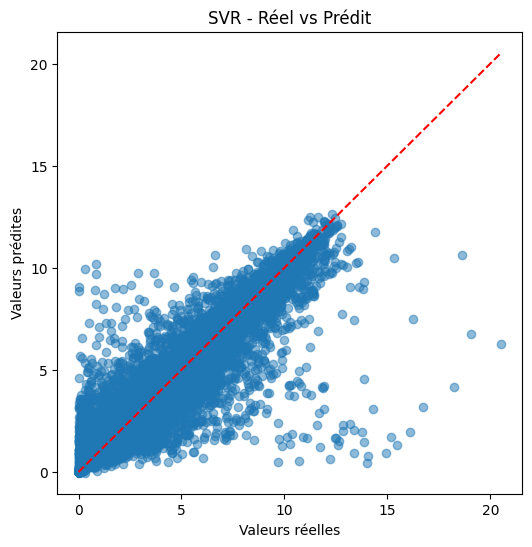

In [133]:
# Prédictions
y_pred_svr = final_svr.predict(X_test_svr)
y_pred_train_svr = final_svr.predict(X_train_svr)

# Évaluation
mae_svr = mean_absolute_error(y_test_svr, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_svr, y_pred_svr))
r2_test_svr = r2_score(y_test_svr, y_pred_svr)
r2_train_svr = r2_score(y_train_svr, y_pred_train_svr)
mae_rel_svr = mae_svr / y_test_svr.mean() * 100

print("\n--- Résultats SVR ---")
print("MAE         :", mae_svr)
print(f"MAE relatif : {round(mae_rel_svr, 3)}%")
print("RMSE        :", rmse_svr)
print("R² train    :", r2_train_svr)
print("R² test     :", r2_test_svr)

plt.figure(figsize=(6,6))
plt.scatter(y_test_svr, y_pred_svr, alpha=0.5)
plt.plot([y_test_svr.min(), y_test_svr.max()],
         [y_test_svr.min(), y_test_svr.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("SVR - Réel vs Prédit")
plt.show()

In [131]:
results = pd.DataFrame({
    "y_true": y_test_rf,
    "y_pred": y_pred
}, index=y_test_rf.index)

results["residual"] = results["y_true"] - results["y_pred"]
results["abs_residual"] = np.abs(results["residual"])

outliers = results.sort_values("abs_residual", ascending=False).head(20)

outliers_full = X_test_rf.loc[outliers.index].copy()
outliers_full = outliers_full.join(outliers)

test.loc[outliers.index][['tch_lag_1', 'target_variability', 'hour', 'month', 'ghi_region']]

,tch_lag_1,target_variability,hour,month,ghi_region
77886,74.85,18.22,14,6,384.71
78645,42.72,20.53,9,6,366.52
74714,74.32,15.47,12,4,391.66
75237,47.65,19.05,9,4,390.40
75436,81.08,16.08,13,4,424.02
77402,81.08,14.08,12,5,497.54
75048,74.24,15.17,11,4,428.15
80762,75.54,13.99,12,8,455.18
76774,64.82,16.74,10,5,330.90
78317,41.72,18.62,13,6,107.87


In [ ]:
# # Évaluation
# mae = mean_absolute_error(y_test_etr, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test_etr, y_pred))
# r2_test = r2_score(y_test_etr, y_pred)
# r2_train = r2_score(y_train_etr, y_pred_train)
# mae_rel = mae / y_test_etr.mean() * 100

# print("\n--- Résultats Extra Trees Regressor ---")
# print("MAE         :", mae)
# print(f"MAE relatif : {round(mae_rel, 3)}%")
# print("RMSE        :", rmse)
# print("R² train    :", r2_train)
# print("R² test     :", r2_test)

In [88]:
results = []

models = {
    "lgbm": final_lgbm,
    "xgb": final_xgb,
    "svr": final_svr,
    "rf": final_rf,
    "etr": final_etr
}

X_tests = {
    "lgbm": X_test_lgbm,
    "xgb": X_test_xgb,
    "svr": X_test_svr,
    "rf": X_test_rf,
    "etr": X_test_etr
}

X_trains = {
    "lgbm": X_train_lgbm,
    "xgb": X_train_xgb,
    "svr": X_train_svr,
    "rf": X_train_rf,
    "etr": X_train_etr
}

y_trains = {
    "lgbm": y_train_lgbm,
    "xgb": y_train_xgb,
    "svr": y_train_svr,
    "rf": y_train_rf,
    "etr": y_train_etr
}

y_tests = {
    "lgbm": y_test_lgbm,
    "xgb": y_test_xgb,
    "svr": y_test_svr,
    "rf": y_test_rf,
    "etr": y_test_etr
}


for name, model in models.items():

    X_test = X_tests[name]
    X_train = X_trains[name]
    y_test = y_tests[name]
    y_train = y_trains[name]

    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, y_pred_train)
    mae_rel = mae / y_test.mean() * 100

    results.append({
        "Model": name,
        "MAE": mae,
        "MAE_rel (%)": mae_rel,
        "RMSE": rmse,
        "R2_train": r2_train,
        "R2_test": r2_test
    })

results_df = pd.DataFrame(results)

  Model  MAE  MAE_rel (%)  RMSE  R2_train  R2_test
0  lgbm 0.45        18.50  1.05      0.96     0.90
1   xgb 0.45        18.69  1.05      0.95     0.90
2   svr 0.43        18.04  1.04      0.94     0.90
3    rf 0.45        18.90  1.07      0.97     0.89
4   etr 0.45        18.75  1.06      0.99     0.90


In [91]:
results_df.set_index('Model').sort_values(by='MAE')

,MAE,MAE_rel (%),RMSE,R2_train,R2_test
Model,,,,,
svr,0.43,18.04,1.04,0.94,0.90
lgbm,0.45,18.50,1.05,0.96,0.90
xgb,0.45,18.69,1.05,0.95,0.90
etr,0.45,18.75,1.06,0.99,0.90
rf,0.45,18.90,1.07,0.97,0.89
